## Step 1 — Bring data from SQL into Python



In [1]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="MySQL@2026Strong",
    database="cart2"
)

cursor = conn.cursor()

print("Connected successfully!")

Connected successfully!


In [2]:
print(conn.is_connected())

True


## Step 2 — Load EDA data

In [3]:
query = """
SELECT
    o.order_id,
    o.customer_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.actual_delivery_days,
    o.delivery_delay_days,
    oi.order_value,
    r.review_score
FROM orders o

LEFT JOIN (
    SELECT
        order_id,
        ROUND(SUM(price + freight_value), 2) AS order_value
    FROM order_items
    GROUP BY order_id
) oi
    ON o.order_id = oi.order_id

LEFT JOIN (
    SELECT
        order_id,
        ROUND(AVG(review_score), 2) AS review_score
    FROM order_reviews
    GROUP BY order_id
) r
    ON o.order_id = r.order_id;
"""

eda_df = pd.read_sql(query, conn)

print("Shape:", eda_df.shape)
eda_df.head()

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_724\2388662370.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  eda_df = pd.read_sql(query, conn)


Shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,actual_delivery_days,delivery_delay_days,order_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:00,7.0,-9.0,72.19,5.0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:00,16.0,-3.0,259.83,4.0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:00,8.0,-14.0,216.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:00,6.0,-6.0,25.78,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:00,25.0,-16.0,218.04,5.0


In [7]:
print("Shape:", eda_df.shape)
eda_df.head()

Shape: (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,actual_delivery_days,delivery_delay_days,order_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:00,7.0,-9.0,72.19,5.0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:00,16.0,-3.0,259.83,4.0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:00,8.0,-14.0,216.87,5.0
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:00,6.0,-6.0,25.78,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:00,25.0,-16.0,218.04,5.0


## Step 3 — Numerical summary


In [8]:
eda_df[['order_value',
        'actual_delivery_days',
        'delivery_delay_days',
        'review_score']].describe()

,order_value,actual_delivery_days,delivery_delay_days,review_score
count,98666.000000,96476.000000,96476.000000,98673.000000
mean,160.577638,12.497336,-11.876881,4.086793
std,220.466087,9.555460,10.183854,1.346274
min,9.590000,0.000000,-147.000000,1.000000
25%,61.980000,7.000000,-17.000000,4.000000
50%,105.290000,10.000000,-12.000000,5.000000
75%,176.870000,16.000000,-7.000000,5.000000
max,13664.080000,210.000000,188.000000,5.000000


In [ ]:
| Variable       |        Mean |  Median | Key observation                                  |
| -------------- | ----------: | ------: | ------------------------------------------------ |
| Order Value    |     ₹160.58 | ₹105.29 | Mean > median → right-skewed                     |
| Delivery Days  |       12.50 |      10 | Some very long deliveries                        |
| Delivery Delay | -11.88 days |     -12 | Most orders were delivered before estimated date |
| Review Score   |        4.09 |       5 | Ratings are concentrated toward 4–5              |


In [ ]:
There are some missing values, which is normal:

order_value: 775 missing
actual_delivery_days: 2,965 missing
delivery_delay_days: 2,965 missing
review_score: 768 missing

The ₹13,664.08 maximum order value and 210-day maximum delivery time also indicate some outliers.

## 1.Univariate Analysis.Order Value Distribution

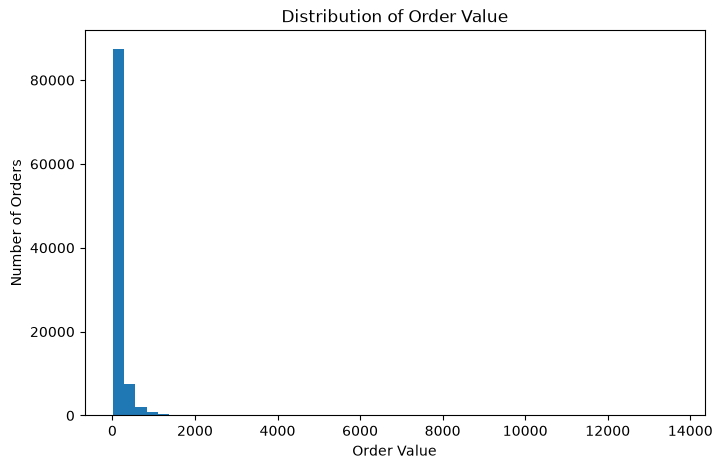

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    eda_df['order_value'].dropna(),
    bins=50
)

plt.xlabel('Order Value')
plt.ylabel('Number of Orders')
plt.title('Distribution of Order Value')

plt.show()

## Interpretation

>>Skewness: The data is positively skewed, meaning a few orders have very high values compared to the majority.
>>Outliers: Those bars far to the right could represent outlier orders — perhaps bulk or special purchases.
>>Common range: Most orders fall within a relatively small range (likely below 2000 on the x-axis).
>>Business insight: If this represents order amounts or quantities, it indicates that small orders dominate, and large ones are rare 
  but may have significant impact on revenue.

## Order Value Distribution:
The distribution is positively skewed, with most orders concentrated at relatively low values and a small number of high-value orders.
forming a long right tail. These high-value orders can have a significant effect on total revenue. The presence of extreme values suggests that 
outlier analysis may be useful.

C:\Users\VIDYAPRIYA V\AppData\Local\Temp\ipykernel_724\382994901.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


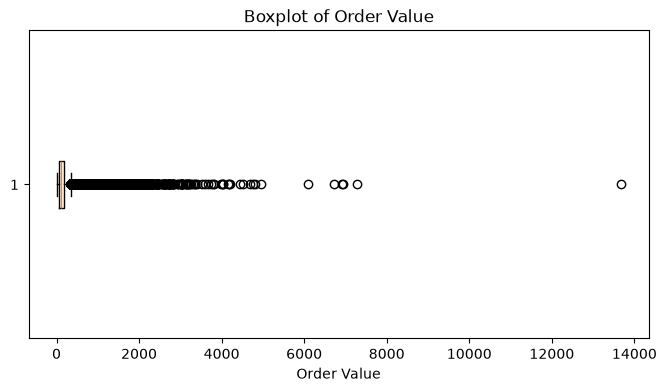

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.boxplot(
    eda_df['order_value'].dropna(),
    vert=False
)

plt.xlabel('Order Value')
plt.title('Boxplot of Order Value')

plt.show()

## Boxplot Analysis: 
Most order values are concentrated near the lower end of the distribution. 
Numerous extreme observations extend to approximately ₹13,664, indicating significant high-value order outliers. 
These observations can strongly influence mean-based statistics and may require log transformation or other scaling techniques 
when the data is used for machine-learning models.

In [11]:
## customer/order segmentation
eda_df['order_value_range'] = pd.cut(
    eda_df['order_value'],
    bins=[0, 100, 500, 1000, 2000, float('inf')],
    labels=[
        '₹0–100',
        '₹101–500',
        '₹501–1000',
        '₹1001–2000',
        'Above ₹2000'
    ]
)

order_segments = (
    eda_df.groupby('order_value_range', observed=True)
    .agg(
        order_count=('order_id', 'count'),
        total_revenue=('order_value', 'sum'),
        average_order_value=('order_value', 'mean')
    )
    .reset_index()
)

order_segments

,order_value_range,order_count,total_revenue,average_order_value
0,₹0–100,46905,2825126.92,60.230827
1,₹101–500,47528,9097021.62,191.403417
2,₹501–1000,3085,2100110.81,680.749047
3,₹1001–2000,939,1252307.30,1333.660596
4,Above ₹2000,209,568986.59,2722.423876


| Order Value Range | Orders | Total Revenue | Avg. Order Value |
| ----------------- | -----: | ------------: | ---------------: |
| ₹0–100            | 46,905 | ₹28,25,126.92 |           ₹60.23 |
| ₹101–500          | 47,528 | ₹90,97,021.62 |          ₹191.40 |
| ₹501–1,000        |  3,085 | ₹21,00,110.81 |          ₹680.75 |
| ₹1,001–2,000      |    939 | ₹12,52,307.30 |        ₹1,333.66 |
| Above ₹2,000      |    209 |  ₹5,68,986.59 |        ₹2,722.42 |

## Interpretation

₹101–500 is the largest segment, with 47,528 orders and approximately ₹90.97 lakh revenue.
₹0–100 also has a very large number of orders, 46,905, but generates much less revenue because the average order value is only ₹60.23.

Orders above ₹500 are relatively few, but their average order values are much higher.
The Above ₹2,000 segment has only 209 orders, but its average order value is ₹2,722.42.

Therefore, the dataset shows that order volume is concentrated in lower-value orders, while higher-value segments contribute substantial 
revenue despite having fewer orders.

Order Value Segmentation: 
Most orders fall within the ₹0–500 range, with the ₹101–500 segment having the highest order count and revenue contribution. 
Higher-value orders occur less frequently but have substantially higher average order values. This indicates a right-skewed order-value distribution,
with a small number of high-value orders contributing significantly to overall revenue.

In [12]:
## Univariate Analysis of Order Status
order_status_counts = (
    eda_df['order_status']
    .value_counts()
    .reset_index()
)

order_status_counts.columns = ['order_status', 'order_count']

order_status_counts

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [ ]:
| Order Status | Orders | Approx. Share |
| ------------ | -----: | ------------: |
| Delivered    | 96,478 |         97.0% |
| Shipped      |  1,107 |          1.1% |
| Canceled     |    625 |          0.6% |
| Unavailable  |    609 |          0.6% |
| Invoiced     |    314 |          0.3% |
| Processing   |    301 |          0.3% |
| Created      |      5 |         <0.1% |
| Approved     |      2 |         <0.1% |


## Interpretation

Delivered orders dominate the dataset, with 96,478 orders, approximately 97% of all orders.
Shipped orders are the second-largest group with 1,107 orders.
625 orders were canceled and 609 were unavailable.
The remaining statuses represent orders that were still in earlier stages of the order lifecycle.
The strong concentration in the delivered category is expected to affect analyses involving delivery time and reviews because those metrics 
are mainly available for completed orders.

Order Status Distribution: 
The dataset is highly concentrated in delivered orders, which account for approximately 97% of all orders. Shipped, canceled, and 
unavailable orders represent much smaller proportions, while created, approved, processing, and invoiced orders form only a small fraction 
of the dataset.

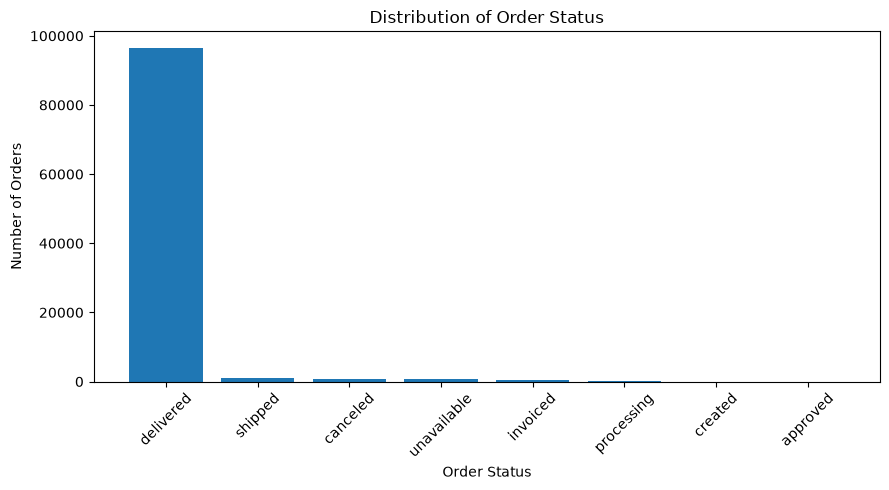

In [13]:
## visualize this distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    order_status_counts['order_status'],
    order_status_counts['order_count']
)

plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.title('Distribution of Order Status')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart clearly shows that delivered orders dominate the dataset, with 96,478 orders (approximately 97% of all orders). 
All other statuses—shipped, canceled, unavailable, invoiced, processing, created, and approved—have substantially smaller counts.
This indicates that the dataset is heavily concentrated on completed orders.

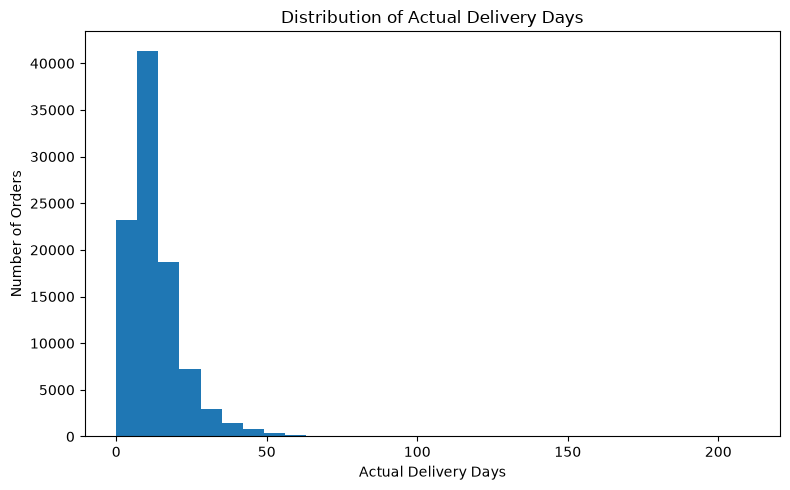

In [14]:
## Delivery Days Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    eda_df['actual_delivery_days'].dropna(),
    bins=30
)

plt.xlabel('Actual Delivery Days')
plt.ylabel('Number of Orders')
plt.title('Distribution of Actual Delivery Days')

plt.tight_layout()
plt.show()

## Actual Delivery Days Distribution: 
The distribution is right-skewed, with most orders delivered within approximately 0–20 days. A smaller number of orders take considerably longer, 
with deliveries beyond 50 days being relatively uncommon. The long right tail indicates the presence of unusually long delivery times and potential 
outliers. The concentration of orders at lower delivery times shows that most completed orders were delivered within a relatively short period.

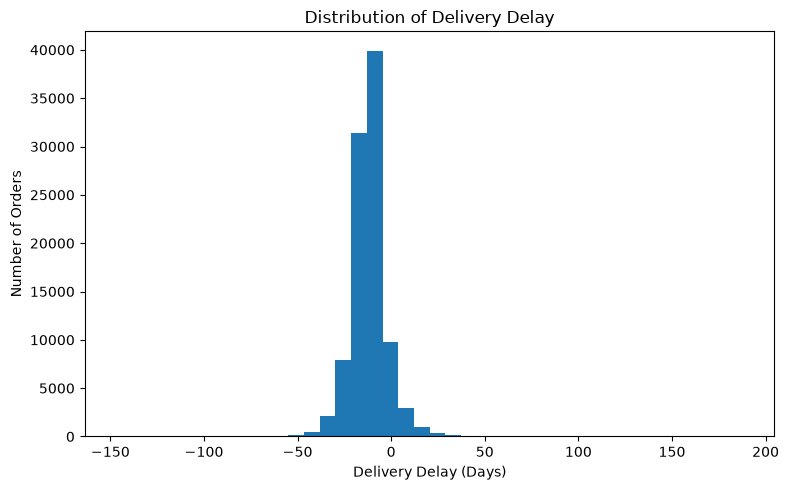

In [15]:
## Delivery Delay Distribution
plt.figure(figsize=(8, 5))

plt.hist(
    eda_df['delivery_delay_days'].dropna(),
    bins=40
)

plt.xlabel('Delivery Delay (Days)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Delivery Delay')

plt.tight_layout()
plt.show()

## Delivery Delay Distribution: 
The distribution is concentrated on the negative side, indicating that many orders were delivered earlier than the estimated delivery date. 
Positive values represent delayed deliveries and occur less frequently. The distribution has a long tail on both sides, including some unusually 
early and late deliveries. Overall, the negative mean delay of 11.88 days indicates that orders were generally delivered earlier than the estimated 
date.

In [16]:
## Review Score Distribution
review_counts = (
    eda_df['review_score']
    .value_counts()
    .sort_index()
)

review_counts

review_score
1.00    11316
1.50        8
2.00     3125
2.50       34
3.00     8136
3.33        1
3.50       25
4.00    19018
4.33        1
4.50       54
5.00    56955
Name: count, dtype: int64

## Review Score Distribution

The major pattern is:

5.0: 56,955 reviews — largest group
4.0: 19,018 reviews
1.0: 11,316 reviews
3.0: 8,136 reviews
2.0: 3,125 reviews
Fractional scores are very small in number.

This is consistent with the overall average review score of approximately 4.09/5.

## Review Score Distribution:
The review scores are strongly concentrated toward higher ratings, with 5.0 being the most frequent score, followed by 4.0.
Lower ratings such as 1.0, 2.0, and 3.0 occur less frequently. A small number of fractional review scores are also present.
Overall, the distribution indicates that customer reviews are concentrated toward the higher end of the rating scale, with an average
score of approximately 4.09 out of 5.

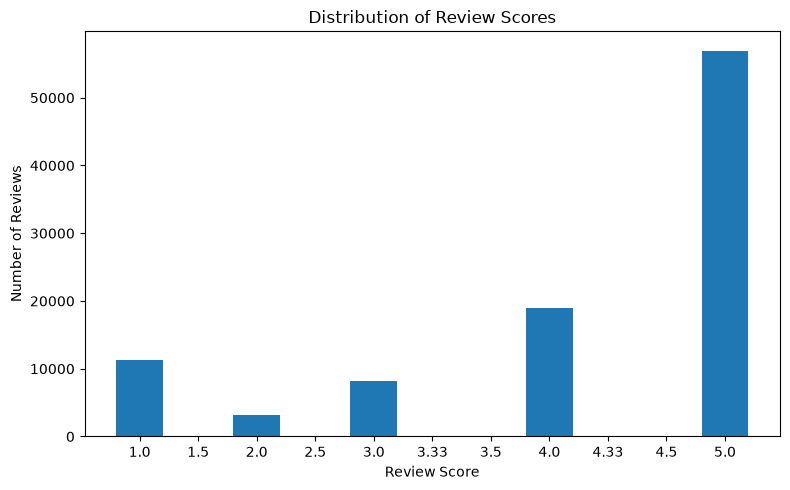

In [17]:
## Distribution of review scores
plt.figure(figsize=(8, 5))

plt.bar(
    review_counts.index.astype(str),
    review_counts.values
)

plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Review Scores')

plt.tight_layout()
plt.show()

The overall interpretation is:

5.0 has 56,955 reviews, not merely “over 40,000.”
4.0 has 19,018 reviews.
1.0 has 11,316 reviews, so low ratings are not minimal; they are a meaningful portion of the data.
Scores 2.0 and 3.0 have 3,125 and 8,136 reviews respectively.

Review Score Distribution: 
The score of 5.0 is the most frequent rating, with 56,955 reviews, followed by 4.0 with 19,018 reviews. Lower ratings are less frequent than the highest ratings, but 1.0-star reviews still account for 11,316 observations and therefore represent a meaningful portion of the dataset. Overall, the distribution is concentrated toward higher review scores, consistent with the overall average rating of approximately 4.09/5.


## 2.Bivariate Analysis

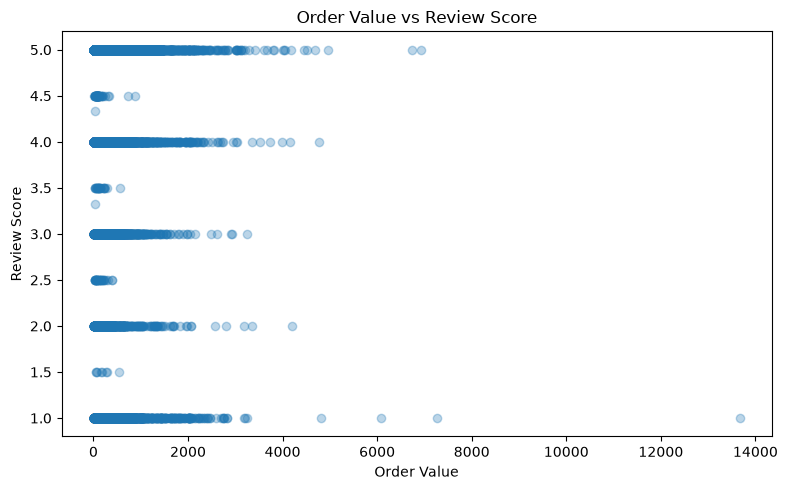

In [18]:
## Order Value vs Review Score
plt.figure(figsize=(8, 5))

plt.scatter(
    eda_df['order_value'],
    eda_df['review_score'],
    alpha=0.3
)

plt.xlabel('Order Value')
plt.ylabel('Review Score')
plt.title('Order Value vs Review Score')

plt.tight_layout()
plt.show()

Order Value vs Review Score: The scatter plot shows distinct horizontal bands because review scores are recorded mainly on a discrete rating scale.
There is no obvious visual relationship between order value and review score, suggesting that higher-value orders do not necessarily receive higher 
ratings. Most observations are concentrated below approximately ₹2,000, consistent with the order-value distribution. A small number of high-value 
orders above ₹10,000 appear across different review scores, indicating that expensive orders can receive varied customer feedback.

In [19]:
## Calculate the actual correlation
correlation = eda_df[
    ['order_value', 'actual_delivery_days',
     'delivery_delay_days', 'review_score']
].corr()

correlation

,order_value,actual_delivery_days,delivery_delay_days,review_score
order_value,1.000000,0.069854,-0.017702,-0.046690
actual_delivery_days,0.069854,1.000000,0.607665,-0.334179
delivery_delay_days,-0.017702,0.607665,1.000000,-0.266990
review_score,-0.046690,-0.334179,-0.266990,1.000000


In [ ]:
| Variables                             | Correlation | Interpretation                         |
| ------------------------------------- | ----------: | -------------------------------------- |
| Order Value ↔ Actual Delivery Days    |   **0.070** | Very weak positive relationship        |
| Order Value ↔ Delivery Delay          |  **−0.018** | Almost no linear relationship          |
| Order Value ↔ Review Score            |  **−0.047** | Very weak negative relationship        |
| Actual Delivery Days ↔ Delivery Delay |   **0.608** | Moderate positive relationship         |
| Actual Delivery Days ↔ Review Score   |  **−0.334** | Moderate negative relationship         |
| Delivery Delay ↔ Review Score         |  **−0.267** | Weak-to-moderate negative relationship |


## Key Findings

1. Order Value vs. Review Score: r = −0.047

This correlation is extremely close to zero, indicating that higher-value orders do not exhibit a meaningful linear relationship with review scores. This finding is consistent with the pattern observed in the scatter plot.

2. Actual Delivery Days vs. Review Score: r = −0.334

This represents the more notable relationship in the analysis. Longer actual delivery times are associated with lower review scores, reflecting a moderate negative correlation. It is important to note, however, that correlation does not establish that longer delivery times directly cause lower ratings.

3. Delivery Delay vs. Review Score: r = −0.267

Orders with greater delivery delays tend to receive lower review scores. This finding reinforces the earlier observation that delayed orders were associated with substantially lower average ratings.

4. Actual Delivery Days vs. Delivery Delay: r = 0.608

This is the strongest relationship identified in the correlation matrix. Orders that take longer to reach customers tend to correspond with larger delivery delays.

Conclusion

Correlation Analysis: Order value shows almost no linear relationship with review score (r = −0.047). In contrast, actual delivery time exhibits a moderate negative correlation with review score (r = −0.334), and delivery delay similarly shows a negative correlation with review score (r = −0.267). Actual delivery days and delivery delay demonstrate a moderate positive correlation (r = 0.608). Collectively, these results suggest that delivery performance is more closely associated with customer ratings than order value is within this dataset.

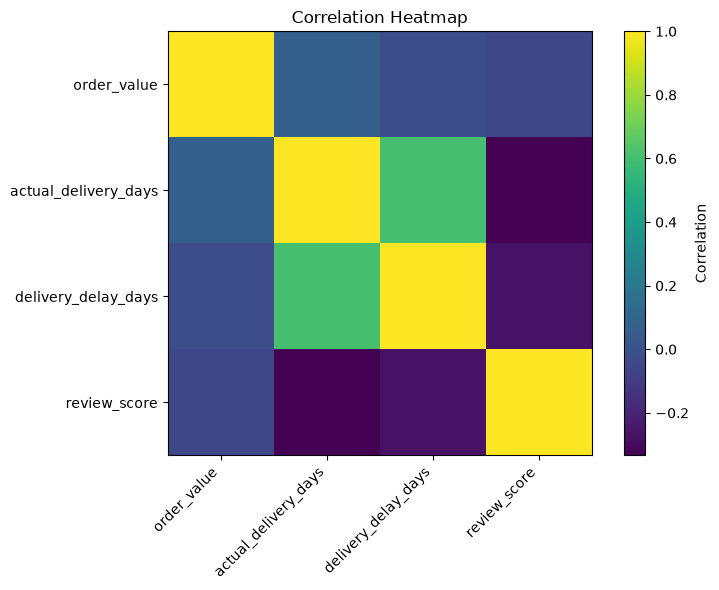

In [20]:
## Correlation Heatmap
plt.figure(figsize=(8, 6))

plt.imshow(correlation, interpolation='nearest')

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar(label='Correlation')

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

## Corrected interpretation
Diagonal: Each variable exhibits a perfect positive correlation with itself (r = 1.00), as expected.

Order Value vs. Review Score: The correlation is −0.047, indicating an extremely weak relationship. This suggests essentially no meaningful linear association between order value and review score.

Actual Delivery Days vs. Delivery Delay: The correlation is 0.608, reflecting a moderate positive relationship. Orders that take longer to deliver tend to also experience greater delivery delays.

Order Value vs. Delivery Metrics:

Relationship	                        Correlation
Order value vs. actual delivery days	0.070
Order value vs. delivery delay	        −0.018

Both correlations are very weak rather than moderate, indicating that order value does not appear to have a meaningful linear relationship with delivery performance.

Delivery Performance vs. Review Score:

Relationship	                       Correlation
Actual delivery days vs. review score	−0.334
Delivery delay vs. review score	        −0.267

These negative relationships indicate that longer delivery durations and greater delays are associated with lower review scores.

Conclusion

Correlation Analysis: The correlation matrix indicates that order value has very weak relationships with both delivery performance and review scores. The strongest relationship observed is between actual delivery days and delivery delay (r = 0.608). Delivery duration and delivery delay also show negative associations with review scores, at −0.334 and −0.267 respectively. These findings suggest that delivery-related factors are more strongly associated with customer ratings than order value is, within this dataset.

## 3.Multivariate Analysis

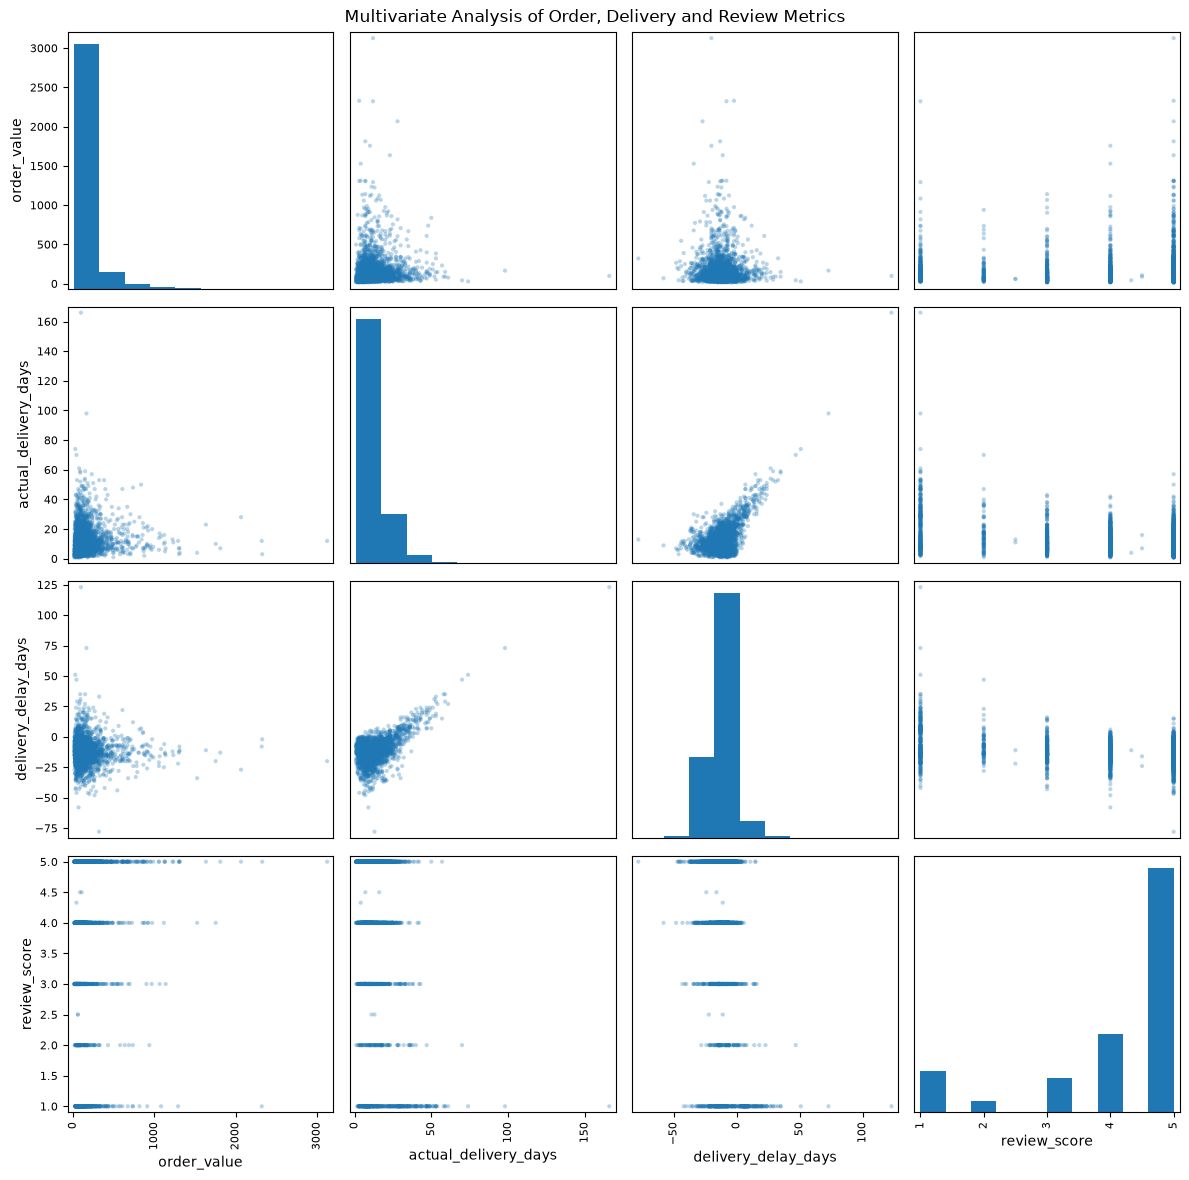

In [21]:
sample_df = eda_df[
    ['order_value',
     'actual_delivery_days',
     'delivery_delay_days',
     'review_score']
].dropna().sample(3000, random_state=42)

pd.plotting.scatter_matrix(
    sample_df,
    figsize=(12, 12),
    diagonal='hist',
    alpha=0.3
)

plt.suptitle('Multivariate Analysis of Order, Delivery and Review Metrics')

plt.tight_layout()
plt.show()

## Multivariate Analysis — Final Interpretation

>>Order Value
The distribution of order value is strongly right-skewed, with the majority of orders clustered at relatively low values and a small number of high-value outliers extending the upper range.

>>Actual Delivery Days vs. Delivery Delay
A strong positive relationship exists between actual delivery duration and delivery delay, supported by a correlation coefficient of 0.608. Longer delivery times are consistently associated with greater delays.

>>Review Score
The horizontal banding observed in the data reflects the discrete nature of review scores, which range from 1 to 5. A pronounced concentration at the 5-star rating indicates that high customer ratings are the norm within this dataset.

>>Order Value vs. Review Score
No strong relationship is observed between order value and review score. Higher spending does not necessarily correlate with higher customer satisfaction ratings.

>>Delivery Delay vs. Review Score
Longer delivery delays correspond to lower review scores, supported by a negative correlation (r = −0.267), indicating that as delays increase, customer satisfaction tends to decline.

>>Overall Conclusion
The multivariate analysis suggests that delivery-related factors exhibit a stronger relationship with customer satisfaction than order value does within this dataset. It is important to note that these findings represent associations rather than causal relationships.